# makemore: part 3

In [17]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [18]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [19]:
len(words)

32033

In [20]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [21]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [134]:
n_embd =  10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0
b1 = torch.randn(n_hidden,                        generator=g) * 0
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total

for p in parameters:
  p.requires_grad = True

11697


In [109]:
hpreact.shape

torch.Size([32, 200])

In [107]:
torch.transpose(W1, 0, 1)[0]

tensor([-0., -0., -0., 0., 0., -0., 0., -0., -0., 0., 0., 0., -0., 0., -0., -0., -0., -0., 0., 0., -0., -0., -0., 0.,
        -0., -0., 0., 0., -0., -0.], grad_fn=<SelectBackward0>)

In [ ]:
emb.shape

embcat = emb.view(emb.shape[0], -1)

torch.Size([32, 3, 10])

(array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        , 49.99997318,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ]),
 array([-0.46296296, -0.44296294, -0.42296296, -0.40296295, -0.38296294,
        -0.36296296, -0.34296295, -0.32296294, -0.30296296, -0.28296298,
        -0.26296297, -0.24296296, -0.22296296, -0.20296296, -0.18296295,
        -0.16296297, -0.14296296, -0.12296295, -0

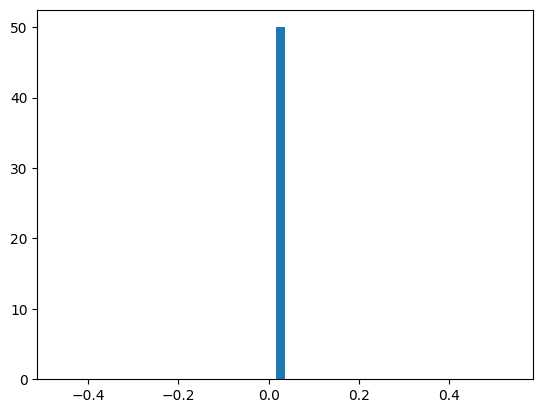

In [85]:
h_plot = h.view(-1,).detach().numpy()
#plt.hist(h_plot,50,density=True)
W2_plot = W2.view(-1,).detach().numpy()
#plt.hist(W2_plot,50,density=True)
logits_plot = logits.detach()

logits_plot = logits_plot.exp()
probs = logits_plot/logits_plot.sum(1,keepdims=True)
plt.hist(probs.view(-1,),50,density=True)

In [135]:
# A dictionary to store the data we capture
data_stats = {'embcat': {'activations': [], 'grads': []},
              'h':      {'activations': [], 'grads': []},
              'logits': {'activations': [], 'grads': []}}

def capture_grad_hook(name):
    # This hook will be registered on TENSORS
    # 'grad' is the argument passed to the backward hook
    def hook_fn(grad):
        if name not in data_stats:
            data_stats[name] = {'activations': [], 'grads': []}

        # The 'grad' passed to the backward hook is the gradient *of the output*
        # w.r.t. the tensor the hook is registered on.
        # We'll capture the magnitude (L2 norm or just the raw array for simplicity)

        # For activations, we'll capture it in the main loop before loss.backward()
        # For gradients, we use this hook.
        data_stats[name]['grads'].append(grad.detach().cpu().numpy())
    
    return hook_fn

In [136]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation

  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  
  logits = h @ W2 + b2 # output layer

  loss = F.cross_entropy(logits, Yb) # loss function

  # --- Capture Activations and Register Backward Hooks ---
    
    # 1. Capture ACTIVATIONS (before loss.backward())
  data_stats['embcat']['activations'].append(embcat.detach().cpu().numpy())
  data_stats['h']['activations'].append(h.detach().cpu().numpy())
  data_stats['logits']['activations'].append(logits.detach().cpu().numpy())
  
  # 2. Register BACKWARD HOOKS
  # Note: These are called when the gradient w.r.t this tensor is computed during loss.backward()
  embcat.register_hook(capture_grad_hook('embcat'))
  h.register_hook(capture_grad_hook('h'))
  logits.register_hook(capture_grad_hook('logits')) # Grad w.r.t logits is the 'output' delta
  W2.register_hook(capture_grad_hook('W2'))
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  

      0/ 200000: 3.2958
  10000/ 200000: 2.6793


KeyboardInterrupt: 

In [117]:
embcat.shape

torch.Size([32, 30])

In [95]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.822659969329834
val 2.8209733963012695


In [ ]:
# Example of target with class indices
input = torch.randn(3, 5, requires_grad=True)
target = torch.randint(5, (3,), dtype=torch.int64)
loss = F.cross_entropy(input, target)

print(input,target,loss)

loss.backward()


tensor([[-1.0494,  1.1990,  1.9756, -0.6734, -0.0029],
        [ 0.2895, -0.6489,  0.4592,  0.0268, -0.2356],
        [ 0.1184,  1.4042,  0.9000,  0.4184,  1.6335]], requires_grad=True) tensor([4, 1, 1]) tensor(2.0280, grad_fn=<NllLossBackward0>)


In [53]:
import math

counts = input.exp() 
probs = counts / counts.sum(1, keepdims=True) 
probs

-(math.log(0.0805) + math.log(0.0994) + math.log(0.2848))/3

2.0280231197738483

In [ ]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) #* (5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) #* 0.01
b2 = torch.randn(vocab_size,                      generator=g) #* 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [7]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


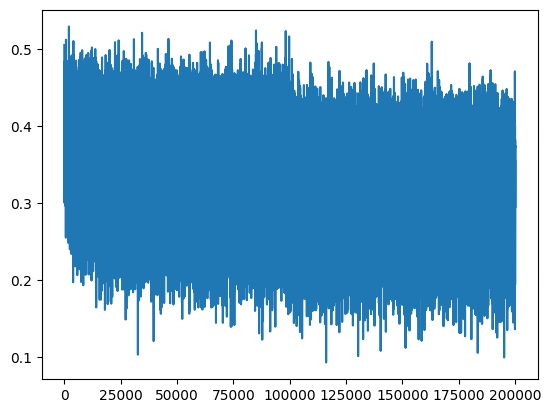

In [87]:
plt.plot(lossi)

In [9]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


In [10]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056840419769287


## loss log

### original:
train 2.1245384216308594
val   2.168196439743042

### fix softmax confidently wrong:
train 2.07
val   2.13

### fix tanh layer too saturated at init:
train 2.0355966091156006
val   2.1026785373687744

### use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693
val   2.106989622116089

### add batch norm layer
train 2.0668270587921143
val 2.104844808578491


In [12]:
# SUMMARY + PYTORCHIFYING -----------

In [163]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  #layers[-1].weight *= 0.0
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 0.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [176]:
with torch.no_grad():
    for i,layer in enumerate(layers[:-1]):
        if isinstance(layer, BatchNorm1d):
            print(f"---------Layer{i}---------")
            print(layer.gamma,layer.beta)
    

---------Layer1---------
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], requires_grad=True) tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.], requires_grad=True)
---------Layer4---------
tensor([1., 1., 1., 

In [164]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

      0/ 200000: 3.2958
  10000/ 200000: 3.0031
  20000/ 200000: 2.7542
  30000/ 200000: 2.5913
  40000/ 200000: 2.7889
  50000/ 200000: 2.7550
  60000/ 200000: 2.7644
  70000/ 200000: 2.8402
  80000/ 200000: 2.9719
  90000/ 200000: 2.9844
 100000/ 200000: 2.8361
 110000/ 200000: 2.8746
 120000/ 200000: 2.8863
 130000/ 200000: 2.5868
 140000/ 200000: 2.5490
 150000/ 200000: 2.6362
 160000/ 200000: 3.0677
 170000/ 200000: 2.7421
 180000/ 200000: 2.9094
 190000/ 200000: 2.6757


layer 2 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 8 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 11 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 14 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

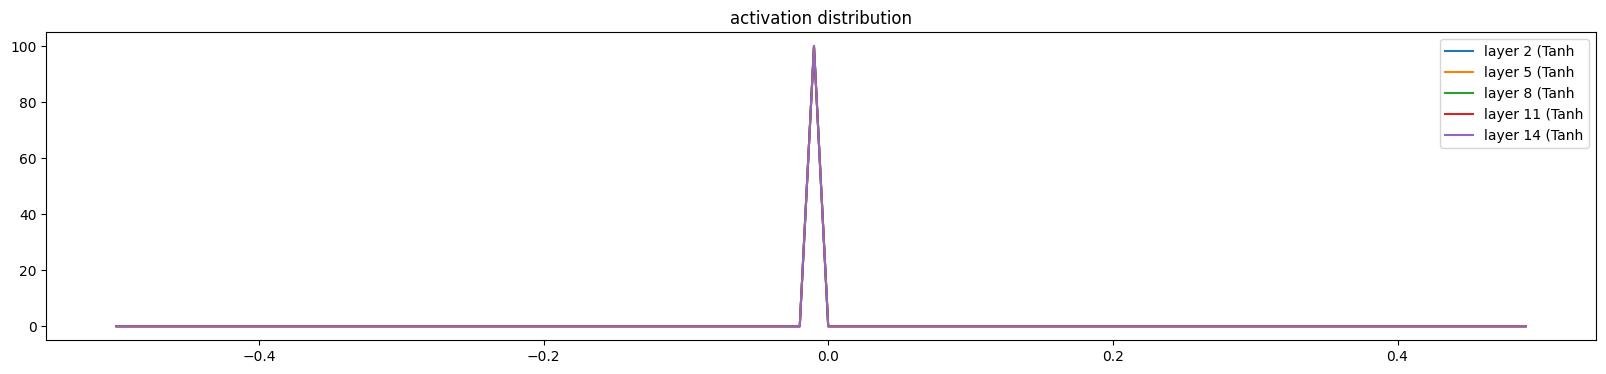

In [175]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

In [174]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

/var/folders/c6/9vr1yrdd4fl8y4xqg65qxmnr0000gn/T/ipykernel_98571/1958459093.py:6: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  t = layer.out.grad


AttributeError: 'NoneType' object has no attribute 'mean'

<Figure size 2000x400 with 0 Axes>

weight   (27, 10) | mean +0.000000 | std 0.000000e+00 | grad:data ratio 0.000000e+00
weight  (30, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight  (100, 27) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan


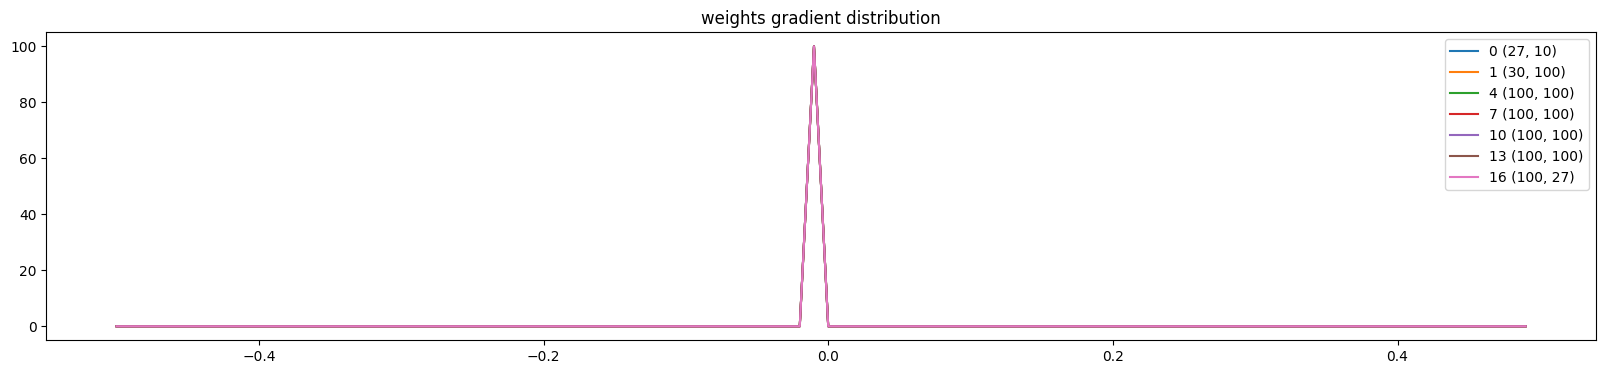

In [167]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

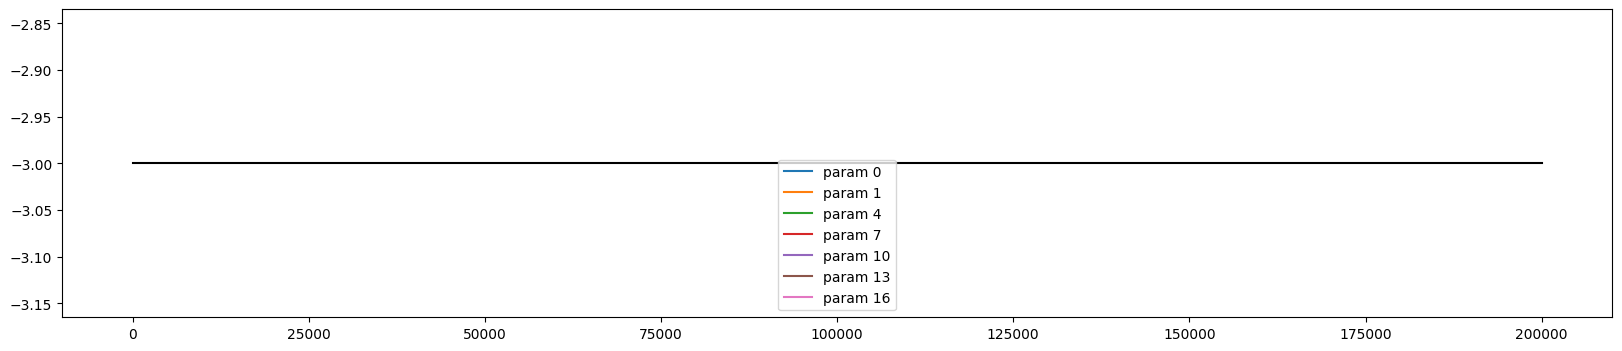

In [168]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [169]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.8227288722991943
val 2.8209996223449707


In [170]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

narmahxaae.
hlrihkimrs.
reaty.
hnaassnejr.
hnenfamesahc.
iaeei.
.
e.
maia.
ceaiiv.
e.
lein.
h.
.
m.
.
oin.
eeijn.
s.
lilea.


In [21]:
# DONE; BONUS content below, not covered in video

In [22]:
# BatchNorm forward pass as a widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):
  
  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5
  x[0] = x0 # override the 0th example with the slider
  mu = x.mean()
  sig = x.std()
  y = (x - mu)/sig

  plt.figure(figsize=(10, 5))
  # plot 0
  plt.plot([-6,6], [0,0], 'k')
  # plot the mean and std
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')
  # plot little lines connecting input and output
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # plot the input and output values
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)
  # title
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));


interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

In [23]:
# Linear: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a
loss = torch.randn(1000, generator=g) @ c
a.retain_grad()
b.retain_grad()
c.retain_grad()
loss.backward()
print('a std:', a.std().item())
print('b std:', b.std().item())
print('c std:', c.std().item())
print('-----')
print('c grad std:', c.grad.std().item())
print('a grad std:', a.grad.std().item())
print('b grad std:', b.grad.std().item())

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [24]:
# Linear + BatchNorm: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

n = 1000
# linear layer ---
inp = torch.randn(n, requires_grad=True, generator=g)
w = torch.randn((n, n), requires_grad=True, generator=g) # / n**0.5
x = w @ inp
# bn layer ---
xmean = x.mean()
xvar = x.var()
out = (x - xmean) / torch.sqrt(xvar + 1e-5)
# ----
loss = out @ torch.randn(n, generator=g)
inp.retain_grad()
x.retain_grad()
w.retain_grad()
out.retain_grad()
loss.backward()

print('inp std: ', inp.std().item())
print('w std: ', w.std().item())
print('x std: ', x.std().item())
print('out std: ', out.std().item())
print('------')
print('out grad std: ', out.grad.std().item())
print('x grad std: ', x.grad.std().item())
print('w grad std: ', w.grad.std().item())
print('inp grad std: ', inp.grad.std().item())

inp std:  0.9875972270965576
w std:  1.0006722211837769
x std:  31.01241683959961
out std:  1.0
------
out grad std:  0.9782556295394897
x grad std:  0.031543977558612823
w grad std:  0.031169468536973
inp grad std:  0.9953052997589111


In [157]:
g = torch.Generator().manual_seed(2147483647)

tensor(0.0023) tensor(1.0057)
tensor(-0.0046) tensor(3.1608)
tensor(-0.0029) tensor(0.8609)


(array([51303.,  8044.,  5018.,  3796.,  3025.,  2537.,  2292.,  2072.,
         1860.,  1701.,  1546.,  1507.,  1449.,  1322.,  1343.,  1256.,
         1223.,  1184.,  1140.,  1124.,  1144.,  1131.,  1089.,  1099.,
         1137.,  1042.,  1073.,  1082.,  1065.,  1186.,  1198.,  1176.,
         1197.,  1188.,  1250.,  1343.,  1382.,  1491.,  1518.,  1524.,
         1683.,  1884.,  1955.,  2211.,  2595.,  3018.,  3727.,  4873.,
         7900., 51097.]),
 array([-1.        , -0.95999998, -0.92000002, -0.88      , -0.84000003,
        -0.80000001, -0.75999999, -0.72000003, -0.68000001, -0.63999999,
        -0.60000002, -0.56      , -0.51999998, -0.48000002, -0.44      ,
        -0.40000004, -0.36000001, -0.31999999, -0.28000003, -0.24000001,
        -0.20000005, -0.16000003, -0.12      , -0.08000004, -0.04000002,
         0.        ,  0.03999996,  0.07999992,  0.12      ,  0.15999997,
         0.19999993,  0.24000001,  0.27999997,  0.31999993,  0.36000001,
         0.39999998,  0.4399999

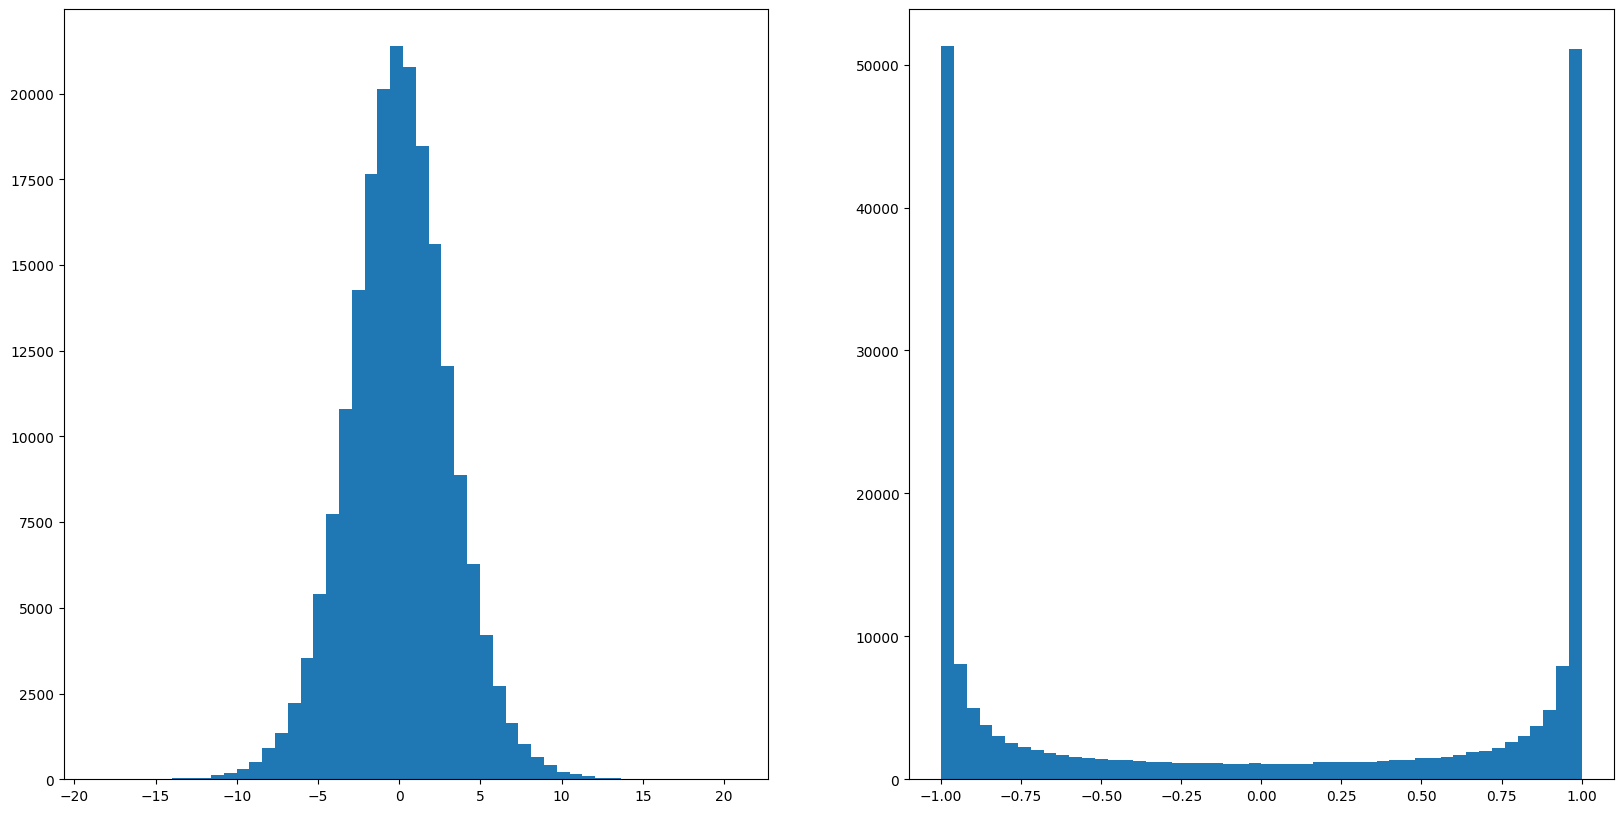

In [158]:
x = torch.randn(1000,10, generator=g)
w1= torch.randn(10,200, generator=g)
y= x @ w1

h = torch.tanh(y)


print(x.mean(),x.std())
print(y.mean(),y.std())
print(h.mean(),h.std())

plt.figure(figsize=(20,10))
plt.subplot(121)
plt.hist(y.view(-1,),50)
plt.subplot(122)
plt.hist(h.view(-1,),50)

In [147]:
h.shape

torch.Size([1000, 200])

tensor(-0.0089) tensor(0.9983)
tensor(0.0019) tensor(0.9858)
tensor(0.0009) tensor(0.6116)


(array([5256., 5274., 4993., 4816., 4530., 4413., 4137., 4108., 3959.,
        3977., 3927., 3856., 3756., 3752., 3654., 3638., 3674., 3678.,
        3572., 3488., 3419., 3426., 3622., 3476., 3569., 3478., 3490.,
        3410., 3488., 3600., 3521., 3553., 3568., 3545., 3628., 3639.,
        3818., 3764., 3778., 4032., 4060., 4064., 4092., 4279., 4404.,
        4468., 4646., 4974., 5419., 5312.]),
 array([-9.99906600e-01, -9.59909141e-01, -9.19911683e-01, -8.79914224e-01,
        -8.39916766e-01, -7.99919307e-01, -7.59921849e-01, -7.19924390e-01,
        -6.79926932e-01, -6.39929473e-01, -5.99932015e-01, -5.59934556e-01,
        -5.19937098e-01, -4.79939640e-01, -4.39942181e-01, -3.99944723e-01,
        -3.59947264e-01, -3.19949806e-01, -2.79952347e-01, -2.39954889e-01,
        -1.99957430e-01, -1.59959972e-01, -1.19962513e-01, -7.99650550e-02,
        -3.99675965e-02,  2.98619270e-05,  4.00273204e-02,  8.00247788e-02,
         1.20022237e-01,  1.60019696e-01,  2.00017154e-01,  2.400146

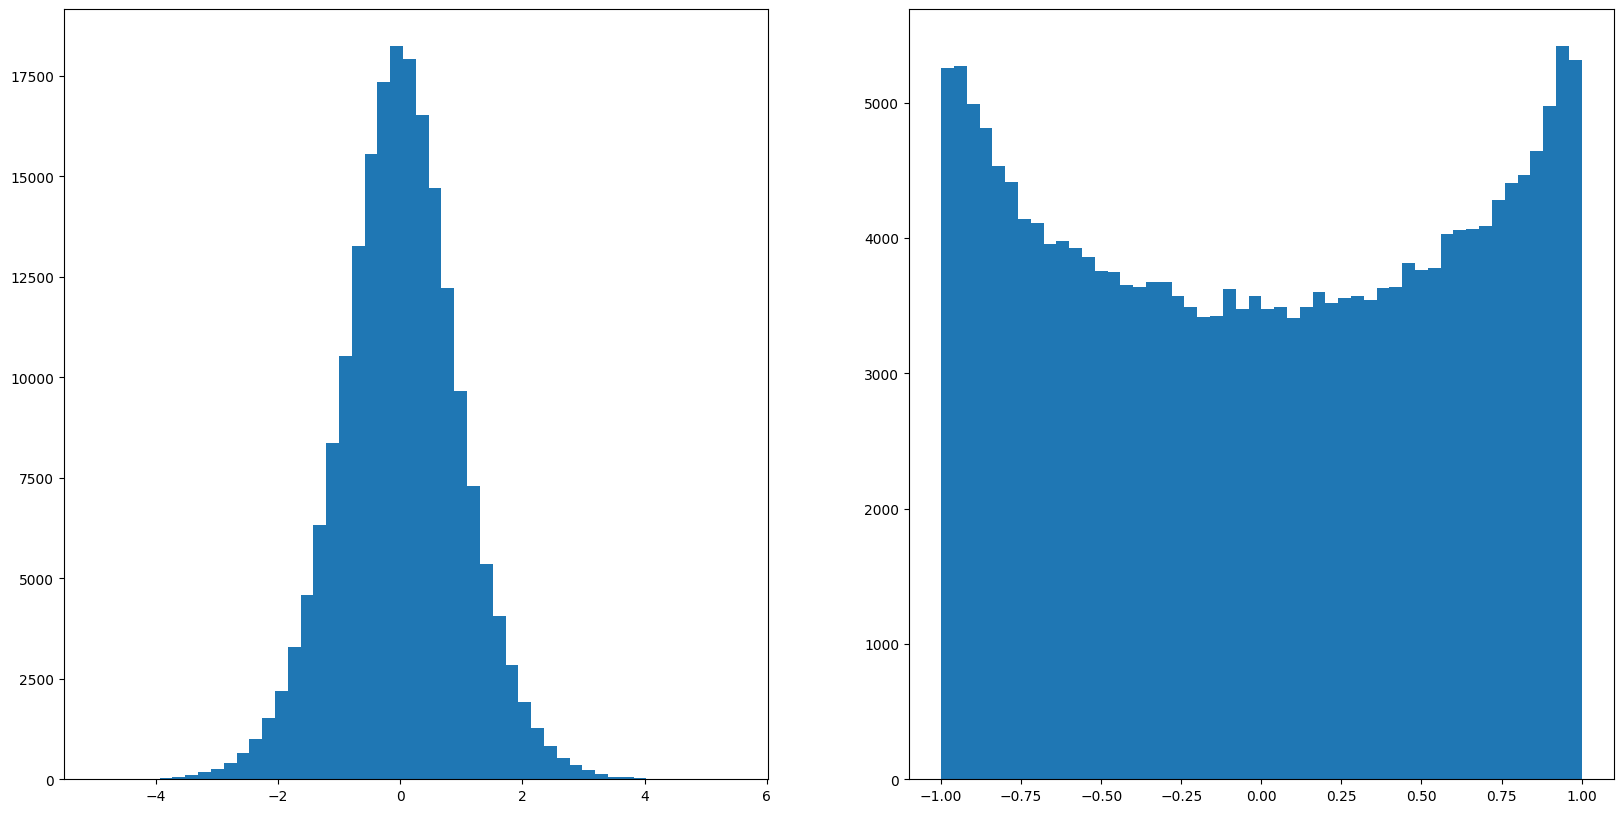

In [159]:


x = torch.randn(1000,10 , generator=g)
w1= torch.randn(10,200, generator=g) / 10 ** 0.5
y= x @ w1

h = torch.tanh(y)


print(x.mean(),x.std())
print(y.mean(),y.std())
print(h.mean(),h.std())

plt.figure(figsize=(20,10))
plt.subplot(121)
plt.hist(y.view(-1,),50)
plt.subplot(122)
plt.hist(h.view(-1,),50)

In [153]:
torch.tanh(torch.tensor(2.0))

tensor(0.9640)

tensor(0.0070) tensor(0.9996)
tensor(-0.0041) tensor(1.6516)
tensor(-0.0019) tensor(0.7397)


(array([21958.,  8947.,  6529.,  5343.,  4579.,  4117.,  3584.,  3381.,
         3209.,  3075.,  2862.,  2692.,  2587.,  2484.,  2434.,  2289.,
         2375.,  2318.,  2216.,  2242.,  2206.,  2227.,  2262.,  2078.,
         2157.,  2138.,  2167.,  2193.,  2123.,  2183.,  2217.,  2250.,
         2320.,  2332.,  2487.,  2424.,  2570.,  2765.,  2785.,  2862.,
         3047.,  3171.,  3271.,  3610.,  4064.,  4425.,  5334.,  6711.,
         8615., 21785.]),
 array([-1.        , -0.95999998, -0.92000002, -0.88      , -0.84000003,
        -0.80000001, -0.75999999, -0.72000003, -0.68000001, -0.63999999,
        -0.60000002, -0.56      , -0.51999998, -0.48000002, -0.44      ,
        -0.40000004, -0.36000001, -0.31999999, -0.28000003, -0.24000001,
        -0.20000005, -0.16000003, -0.12      , -0.08000004, -0.04000002,
         0.        ,  0.03999996,  0.07999992,  0.12      ,  0.15999997,
         0.19999993,  0.24000001,  0.27999997,  0.31999993,  0.36000001,
         0.39999998,  0.4399999

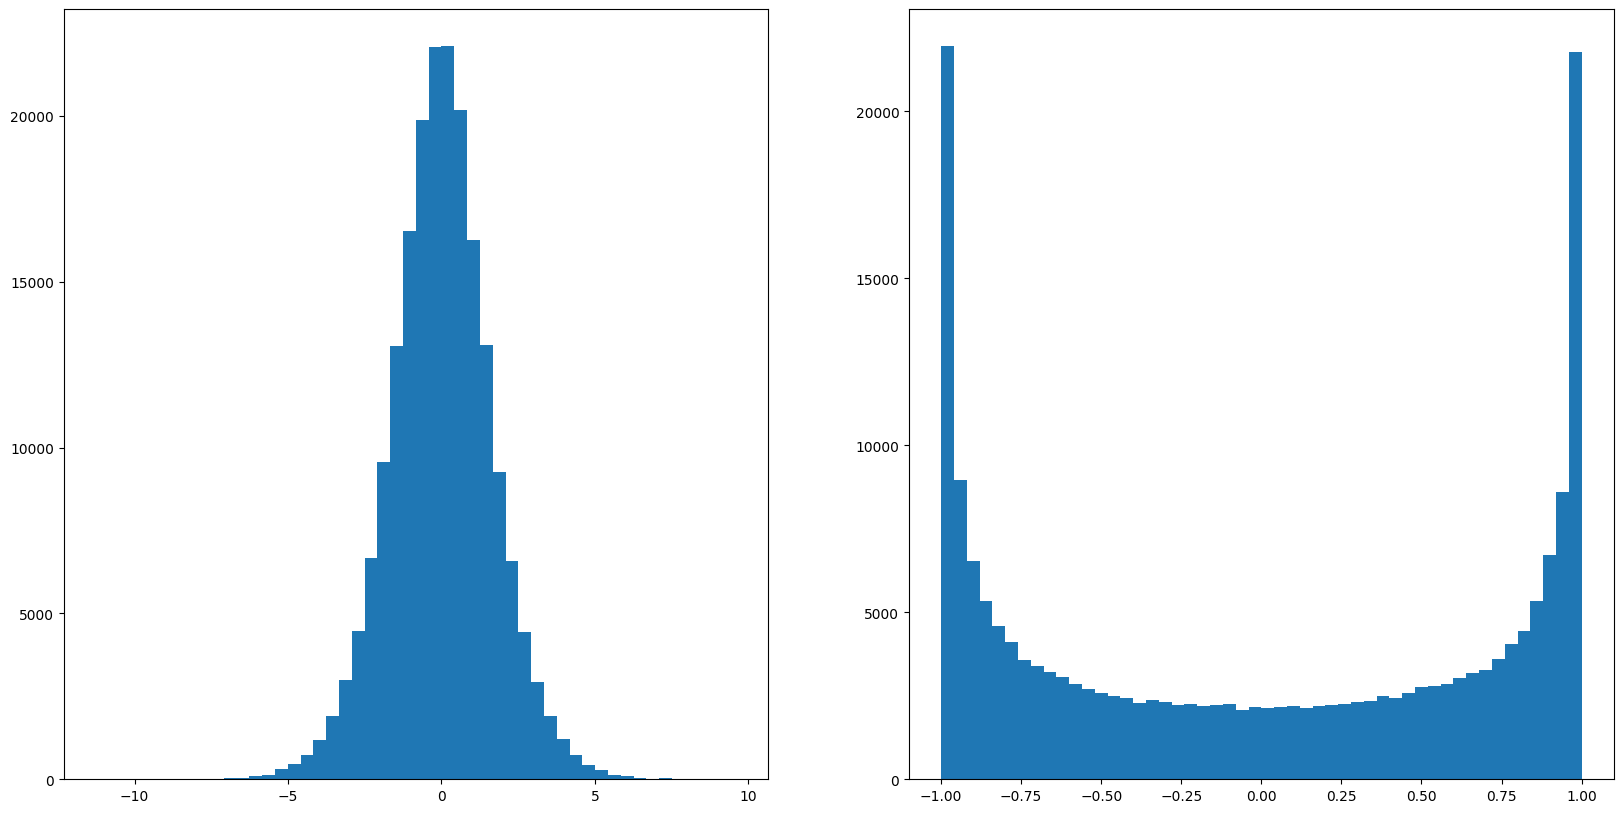

In [160]:
x = torch.randn(1000,10, generator=g)
w1= torch.randn(10,200, generator=g) * ((5/3) / 10 ** 0.5)
y= x @ w1

h = torch.tanh(y)


print(x.mean(),x.std())
print(y.mean(),y.std())
print(h.mean(),h.std())

plt.figure(figsize=(20,10))
plt.subplot(121)
plt.hist(y.view(-1,),50)
plt.subplot(122)
plt.hist(h.view(-1,),50)